In [1]:
import numpy as np
import matplotlib.pyplot as plt

import pickle
import sympy as sp

In [2]:
name = "Lb_0.16_Lc_0.26_ma_2.0_mb_2.2_mc_1.3"
timestamp = "23April26_00Hrs"
filename = f"3DOF_dynamics_sim_equation_{name}_{timestamp}.npz"
with open(filename, "rb") as f:
    data = pickle.load(f)

In [3]:
M_sym = data["M_sym"]
h_sym = data["h_sym"]
Q_sym = data["Q_sym"]
dyn_args = data["dyn_args"]

M_func = sp.lambdify(dyn_args, M_sym, "numpy")
h_func = sp.lambdify(dyn_args, h_sym, "numpy")
Q_func = sp.lambdify(dyn_args, Q_sym, "numpy")


In [4]:
# One fixed parameter set
params = {
    "g": 9.81,
    "ma": 2.0,
    "mb": 2.2,
    "mc": 1.3,

    "Iaxx": 0.01, "Iayy": 0.02, "Iazz": 0.03,
    "Iaxy": 0.0,  "Iaxz": 0.0,  "Iayz": 0.0,

    "Ibx": 0.030, "Iby": 0.025, "Ibz": 0.020,
    "Icx": 0.030, "Icy": 0.025, "Icz": 0.020,

    "xO_A": -0.03, "yO_A": 0.0, "zO_A": -0.06,
    "xB_A":  0.00, "yB_A": 0.0, "zB_A":  0.12,
    "xC_A":  0.00, "yC_A": 0.0, "zC_A": -0.30,
}

In [8]:
def tau_A_numeric(t):
    return np.array([0.01*np.sin(t), 1.0, 0.0], dtype=float)

def F_A_numeric(t):
    return np.array([0.0, 0.0, 0.0], dtype=float)

def qdd_eval(state, t_current):
    qv = state[:3]
    qdv = state[3:]
    tauA = tau_A_numeric(t_current)
    FA = F_A_numeric(t_current)

    vals = (
        qv[0], qv[1], qv[2], qdv[0], qdv[1], qdv[2],
        params["g"], params["ma"], params["mb"], params["mc"],
        params["Iaxx"], params["Iayy"], params["Iazz"], params["Iaxy"], params["Iaxz"], params["Iayz"],
        params["Ibx"], params["Iby"], params["Ibz"], params["Icx"], params["Icy"], params["Icz"],
        params["xO_A"], params["yO_A"], params["zO_A"],
        params["xB_A"], params["yB_A"], params["zB_A"],
        params["xC_A"], params["yC_A"], params["zC_A"],
        tauA[0], tauA[1], tauA[2], FA[0], FA[1], FA[2]
    )

    M = np.array(M_func(*vals), dtype=float)
    h = np.array(h_func(*vals), dtype=float).reshape(3)
    Q = np.array(Q_func(*vals), dtype=float).reshape(3)

    return np.linalg.solve(M, Q - h)

def f_state(state, t_current):
    return np.hstack([state[3:], qdd_eval(state, t_current)])


In [9]:
dt = 0.01
T = 5.0
time = np.arange(0.0, T + dt, dt)

traj = np.zeros((len(time), 6))
traj[0] = np.array([0.0, np.deg2rad(2.0), 0.0, 0.0, 0.0, 0.0])

for i in range(len(time) - 1):
    t = time[i]
    x = traj[i]

    k1 = f_state(x, t)
    k2 = f_state(x + 0.5*dt*k1, t + 0.5*dt)
    k3 = f_state(x + 0.5*dt*k2, t + 0.5*dt)
    k4 = f_state(x + dt*k3, t + dt)

    traj[i + 1] = x + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)


<lambdifygenerated-2>:2: RuntimeWarning: overflow encountered in scalar multiply
  return array([[(1/2)*Ibx*((sin(q1_s)*sin(q3_s) + sin(q2_s)*cos(q1_s)*cos(q3_s))*(q1d_s*sin(q1_s)*sin(q3_s) + q1d_s*sin(q2_s)*cos(q1_s)*cos(q3_s) + q2d_s*sin(q1_s)*cos(q2_s)*cos(q3_s) - q3d_s*sin(q1_s)*sin(q2_s)*sin(q3_s) - q3d_s*cos(q1_s)*cos(q3_s)) + (-sin(q1_s)*cos(q3_s) + sin(q2_s)*sin(q3_s)*cos(q1_s))*(-q1d_s*sin(q1_s)*cos(q3_s) + q1d_s*sin(q2_s)*sin(q3_s)*cos(q1_s) + q2d_s*sin(q1_s)*sin(q3_s)*cos(q2_s) + q3d_s*sin(q1_s)*sin(q2_s)*cos(q3_s) - q3d_s*sin(q3_s)*cos(q1_s)) + (q1d_s*cos(q1_s)*cos(q2_s) - q2d_s*sin(q1_s)*sin(q2_s))*cos(q1_s)*cos(q2_s))*(-4*q1d_s*sin(q1_s)*cos(q1_s)*cos(q2_s)**2 - 4*q2d_s*sin(q2_s)*cos(q1_s)**2*cos(q2_s) + 2*(sin(q1_s)*sin(q3_s) + sin(q2_s)*cos(q1_s)*cos(q3_s))*(-2*q1d_s*sin(q1_s)*sin(q2_s)*cos(q3_s) + 2*q1d_s*sin(q3_s)*cos(q1_s) + 2*q2d_s*cos(q1_s)*cos(q2_s)*cos(q3_s) + 2*q3d_s*sin(q1_s)*cos(q3_s) - 2*q3d_s*sin(q2_s)*sin(q3_s)*cos(q1_s)) + 2*(-sin(q1_s)*cos(q3_s) + sin(q2_

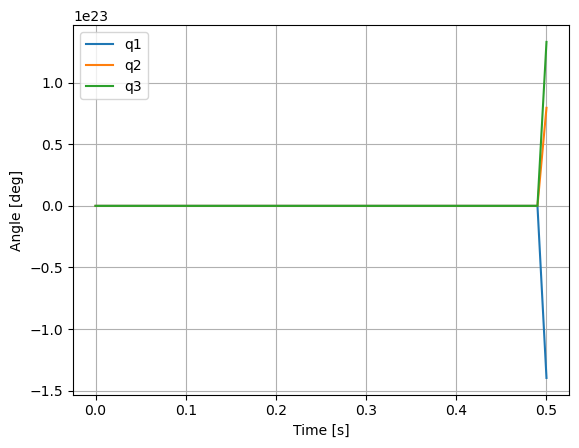

In [10]:
plt.plot(time, np.rad2deg(traj[:, 0]), label="q1")
plt.plot(time, np.rad2deg(traj[:, 1]), label="q2")
plt.plot(time, np.rad2deg(traj[:, 2]), label="q3")
plt.xlabel("Time [s]")
plt.ylabel("Angle [deg]")
plt.legend()
plt.grid(True)
plt.show()